# Civilian HOSTAGE — Fuzzy Mamdani

## Rencana dan Batas Sistem

Notebook fuzzy baru dan mandiri; fuzzy lama, Utility AI, Behavior Tree, dan NLU tidak diubah. Cakupan awal: intent dan target chat Civilian. Tidak mengatur vote atau skill. Tidak ada uang, budget, pembelian, atau tebusan.

**Alur:** chat publik → NLU lokal → target dengan aturan tanpa LLM → parameter per ronde → inferensi fuzzy → keputusan → instruksi untuk penyusun percakapan. Tidak ada pemanggilan LLM/API di notebook ini; LLM kelak hanya menulis percakapan.

**Asumsi event:** ID pesan, pengirim, teks, ronde, fase, waktu, awal siang, roster publik, dan izin chat AI sendiri tersedia. Reply-to opsional. Roster tetap mencakup pemain Hostage/Gag Order; status tersembunyi mereka tidak dipakai untuk menyaring roster.

**Perbaikan dari fuzzy lama:** parameter tidak hanya persentase tuduhan; tuduhan dibatasi per ronde dan pengirim; keputusan terpisah untuk beberapa tindakan; uncertainty ikut dipertimbangkan; seluruh rentang keanggotaan tercakup termasuk tepat 50%; ada trace dan pengujian.

## Parameter yang Bisa dan Belum Bisa Digunakan

Parameter yang benar-benar dihitung dalam versi ini:

| Nama variabel / proses | Untuk apa dan dari mana? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| Intent dan confidence | Teks chat → model SVM/NB/IndoBERT tersimpan dari nlu_baru. | Label offend/defend/neutral. Confidence 0–1 adalah keyakinan klasifikasi intent, bukan keyakinan bahwa tuduhan benar. |
| Target dan sumbernya | Teks + daftar nama/ID publik + reply-to opsional → aturan ekstraksi. | Nama/ID pemain. Kosong berarti neutral atau target belum diketahui, dibedakan lewat intent dan target_source. |
| accusers / defenders | Kelompokkan chat bertarget menurut pengirim, intent, dan ronde. | Jumlah pengirim berbeda, bukan jumlah pesan. Mereka belum tentu independen secara sosial atau berkata benar. |
| pressure / support | Jumlah penuduh/pembela dibagi jumlah pemain lain yang dapat menjadi pengirim. | 0–1. AI dan target tidak menjadi sumber penguat. Nilai tinggi berarti tekanan/dukungan sosial, bukan peluang role. |
| silence | Waktu sekarang dikurangi waktu chat terakhir pada siang ini, dibagi SILENCE_SECONDS. | Dibatasi 0–1. Tidak bisa membedakan diam sukarela, Hostage, Gag Order, atau koneksi terputus. Hanya memicu ajakan bicara. |
| uncertainty | Proporsi chat masuk yang confidence-nya rendah atau target non-neutral-nya tidak terselesaikan. | 0–1. Makin tinggi, makin masuk akal meminta klarifikasi. |
| few_messages | Jumlah chat pemain lain pada ronde ini dibanding MIN_MESSAGES. | Boolean; membantu fuzzy mengutamakan informasi saat pengamatan sedikit. |
| phase / can_chat | Event fase publik dan izin aksi milik AI sendiri. | Hanya day dengan can_chat=True boleh menghasilkan chat; kondisi lain wait. |

Kandidat berikut belum dihitung agar tidak mengarang data atau memakai informasi tersembunyi:

| Nama variabel / proses | Untuk apa dan dari mana? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| Pergantian target tuduhan | Urutan target dari pengirim yang sama per ronde. | Dapat dihitung nanti, tetapi perubahan pendapat bukan otomatis kebohongan. Perlu benchmark target dahulu. |
| Vote, kesesuaian ucapan–vote | Event voting yang memang dibuka kepada pemain. | Belum jelas apakah pilihan per pemain terlihat. Jangan membaca vote privat atau memakai tidak-vote sebagai identitas korban. |
| Klaim role dan kontradiksi | Ekstraksi klaim spesifik + riwayat, bukan classifier tiga intent. | NLU saat ini tidak menghasilkan fakta klaim. Perlu anotasi dan extractor terpisah sebelum dipakai. |
| Hostage/Gag Order pada pemain lain | Tidak ada sumber publik yang pasti sesuai Silent Terror. | Jangan memasukkan status server tersembunyi. Rekap malam tanpa nama target tidak boleh diubah menjadi tuduhan pada nama tertentu. |
| Hasil Peek / Guard | Informasi pribadi Stalker/Spy. | Tidak tersedia bagi Civilian. Klaim chat tentang hasil skill masih merupakan ucapan yang belum terverifikasi. |
| Probabilitas Hitman | Perlu model role dan evaluasi dari riwayat permainan berlabel. | Tidak dihitung pada tahap ini. Skor tekanan maupun utility tidak boleh diberi nama probabilitas Hitman. |

## Library yang Digunakan

In [1]:
from pathlib import Path
import math
import re

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


## Konfigurasi dan Nilai Awal

Angka berikut adalah keputusan desain untuk prototipe. Tidak berasal dari hasil NLU atau penelitian yang menetapkan ambang khusus HOSTAGE. Uji sensitivitas dan evaluasi pertandingan diperlukan sebelum mengklaim nilai terbaik.

| Nama variabel / proses | Untuk apa dan dari mana? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| MIN_INTENT_CONFIDENCE = 0.60 | Menyaring prediksi intent sebelum menghitung tuduhan/pembelaan. | 0.60 berarti 60% confidence model. Lebih besar menyaring lebih banyak chat; threshold perlu dievaluasi untuk tiap backend. |
| MIN_ACCUSERS = 2 | Batas minimum pengirim berbeda untuk menantang pemain lain. | Mengurangi pengaruh spam satu pengirim. Dua orang tetap bisa bersekongkol; ini bukan bukti kebenaran. |
| MIN_PRESSURE = 0.50 | Ambang tekanan sosial untuk tindakan challenge_player. | Setengah sumber pengirim yang memenuhi syarat. Minimal dua penuduh tetap wajib. |
| SILENCE_SECONDS = 60 | Skala waktu diam selama siang. | 60 detik → silence=1. Lebih besar menunda ajakan bicara. Sesuaikan dengan panjang fase diskusi. |
| MIN_MESSAGES = 3 | Batas pengamatan sedikit untuk fuzzy. | Kurang dari tiga chat menaikkan kebutuhan informasi. Input ini masuk ke sistem ask_information sebagai 0 atau 1. |
| PLAYERS / AI_NAME | Roster publik dan ID Civilian yang dikendalikan. | Contoh enam pemain; ganti dengan data game. Jangan menghapus korban Hostage dari roster karena status itu rahasia. |

In [2]:
# Jalankan notebook dari folder ai_2_dataset_baru.
MODEL_DIR = Path("models/notebook_standalone")
NLU_BACKEND = "classical"
MODEL_FILENAME = "intent_classifier_svm.pkl"

# Contoh roster publik; ganti dengan ID pemain dari game.
PLAYERS = ["AI", "A", "B", "C", "D", "E"]
AI_NAME = "AI"

# Nilai awal rancangan, belum hasil optimasi pertandingan.
MIN_INTENT_CONFIDENCE = 0.60
MIN_ACCUSERS = 2
MIN_PRESSURE = 0.50
SILENCE_SECONDS = 60.0
MIN_MESSAGES = 3


## NLU Lokal dan Deteksi Target

### Prediksi Intent

Antarmuka mengikuti nlu_baru: tiga label intent dan confidence. Di sini confidence dibawa dalam skala 0–1 (fungsi notebook NLU menampilkannya 0–100). Model dimuat sekali, bukan setiap chat.

Default memakai intent_classifier_svm.pkl agar integrasi lokal langsung bisa dicoba. Untuk NB, ubah MODEL_FILENAME ke intent_classifier_nb.pkl atau varian tuning. Untuk IndoBERT, ubah NLU_BACKEND menjadi indobert; loader membaca folder model lokal dengan local_files_only=True dan berjalan di CPU. IndoBERT di sini adalah classifier intent, bukan LLM pengambil keputusan.

Belum ada model prediksi target yang dilatih. Menambah kolom target pada dataset tidak otomatis mengubah classifier intent menjadi extractor target.

In [3]:
# Memuat model lokal hasil nlu_baru sekali, tanpa training atau unduhan.
def load_nlu(backend=NLU_BACKEND):
    if backend == "classical":
        path = MODEL_DIR / MODEL_FILENAME
        if not path.is_file():
            raise FileNotFoundError(f"Model tidak ditemukan: {path}. Periksa MODEL_DIR dan MODEL_FILENAME.")
        return {"backend": backend, "model": joblib.load(path)}

    if backend == "indobert":
        import torch
        from transformers import AutoModelForSequenceClassification, AutoTokenizer

        path = MODEL_DIR / "intent_classifier_transformer"
        if not path.is_dir():
            raise FileNotFoundError(f"Model IndoBERT lokal tidak ditemukan: {path}")
        model = AutoModelForSequenceClassification.from_pretrained(path, local_files_only=True)
        model.eval()
        return {
            "backend": backend, "model": model,
            "tokenizer": AutoTokenizer.from_pretrained(path, local_files_only=True),
            "torch": torch,
        }

    raise ValueError("NLU_BACKEND harus classical atau indobert.")


In [4]:
# Mengubah satu chat menjadi label dan confidence 0-1; ini bukan peluang role Hitman.
def predict_nlu(text, runtime):
    model = runtime["model"]
    if runtime["backend"] == "classical":
        label = str(model.predict([text])[0])
        confidence = float(np.max(model.predict_proba([text])[0]))
    else:
        encoded = runtime["tokenizer"](
            text, return_tensors="pt", truncation=True,
            max_length=getattr(model.config, "nlu_max_length", 128),
        )
        with runtime["torch"].inference_mode():
            probabilities = runtime["torch"].softmax(model(**encoded).logits, dim=-1)[0]
        index = int(probabilities.argmax())
        label = str(model.config.id2label[index])
        confidence = float(probabilities[index])

    label = {"offense": "offend", "defense": "defend"}.get(label, label)
    if label not in {"offend", "defend", "neutral"}:
        raise ValueError(f"Label model tidak sesuai: {label}")
    return label, confidence


### Target Tanpa LLM

Resolver aturan ini mengutamakan target eksplisit dan boleh tidak menjawab. Reply-to harus diisi dari metadata server sebagai ID pengirim pesan yang dibalas; mention saja bukan bukti target.

| Nama variabel / proses | Untuk apa dan dari mana? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| offend | Cari pola tuduhan/vote terhadap nama pemain. | Aku curiga B → B. B kena Gag Order → tidak diketahui, karena nama korban bukan otomatis penuduhan. |
| defend | Cari pola pembelaan terhadap nama atau pembicara. | B bukan Hitman → B. Aku bukan Hitman → ID pengirim. |
| diri_sendiri | Kata aku/saya/gw pada posisi target dipetakan ke pengirim. | Vote aku → pengirim. Aku curiga B → B, bukan pengirim. Mendukung offend dan defend. |
| kamu / lu | Pola target orang kedua + reply_to. | Kamu Hitman dengan reply_to=B → B. Tanpa metadata → tidak diketahui. Asumsi percakapan langsung ini tetap perlu diuji. |
| dia / mereka / multi-nama ambigu | Belum ada resolusi acuan bahasa yang andal. | Konservatif: tidak diketahui, bahkan sebagian kasus yang bisa dipahami manusia. Vote B, vote C bisa menghasilkan dua target. |
| neutral | Tidak membuat relasi tuduhan/pembelaan. | Daftar target input kosong. Tindakan neutral keluaran boleh punya penerima, misalnya mengajak B bicara; penerima itu bukan target tuduhan. |

In [5]:
# Mengambil target dengan pola eksplisit; nama yang sekadar disebut tidak otomatis menjadi target.
def extract_targets(text, intent, speaker, players, reply_to=None):
    if intent == "neutral":
        return [], "neutral"

    # Kutipan dan kalimat bersyarat belum aman disimpulkan dengan aturan sederhana.
    if re.search(r"[\"“”]|\b(kalau|jika|seandainya|katanya|bilang|kata|bukan berarti)\b", text, re.I):
        return [], "tidak_diketahui"

    # Pola terbatas; sengaja tidak menebak semua negasi, sarkasme, atau konteks lintas pesan.
    def matches(subject):
        if intent == "offend":
            patterns = [
                rf"\b(?:curiga|mencurigai|tuduh|menuduh|vote|voting|pilih|eksekusi)\s+(?:si\s+)?{subject}",
                rf"{subject}\s+(?:(?:itu|adalah|pasti|jelas|sangat|paling|memang|si)\s+)*(?:hitman|pelaku|mencurigakan|sus|bohong|berbohong)\b",
            ]
            for pattern in patterns:
                for match in re.finditer(pattern, text, re.I):
                    prefix = text[max(0, match.start() - 35):match.start()]
                    if not re.search(r"\b(?:jangan|tidak|tak|bukan|gak|nggak|ga)(?:\s+\w+){0,2}\s*$", prefix, re.I):
                        return True
            return False

        patterns = [
            rf"{subject}\s+(?:itu\s+)?(?:bukan\s+(?:hitman|pelaku)|tidak\s+bersalah|tak\s+bersalah)\b",
            rf"\b(?:bela|membela)\s+(?:si\s+)?{subject}",
            rf"\bjangan\s+(?:tuduh|menuduh|vote|eksekusi)\s+(?:si\s+)?{subject}",
        ]
        for pattern in patterns:
            for match in re.finditer(pattern, text, re.I):
                prefix = text[max(0, match.start() - 35):match.start()]
                if not re.search(r"\b(?:tidak|tak|bukan|gak|nggak|ga)(?:\s+\w+){0,2}\s*$", prefix, re.I):
                    return True
        return False

    targets = []
    for player in players:
        subject = rf"(?<!\w){re.escape(player)}(?!\w)"
        if matches(subject):
            targets.append(player)

    if matches(r"\b(?:aku|saya|gw|gue|gua)\b"):
        targets.append(speaker)

    # reply_to adalah ID pengirim pesan yang dibalas, bukan tebakan dari teks.
    if matches(r"\b(?:kamu|lu|lo|elu)\b"):
        if reply_to in players:
            targets.append(reply_to)
        else:
            return [], "tidak_diketahui"

    # Jangan pakai reply-to untuk menebak 'dia/mereka'.
    if re.search(r"\b(dia|mereka)\b", text, re.I):
        return [], "tidak_diketahui"

    # Nama tambahan yang belum terselesaikan membuat chat multi-target ini ambigu.
    mentioned = [p for p in players if re.search(rf"(?<!\w){re.escape(p)}(?!\w)", text, re.I)]
    if any(p not in targets for p in mentioned):
        return [], "tidak_diketahui"

    targets = sorted(set(targets))
    return targets, "aturan_teks" if targets else "tidak_diketahui"


Keterbatasan penting: ini baseline aturan, bukan parser bahasa Indonesia lengkap. Sarkasme, typo, negasi kompleks, kutipan tidak bertanda, dan kalimat majemuk dapat gagal. Jangan melaporkan target accuracy dari contoh buatan saja. Pengembangan berikutnya yang disarankan adalah anotasi relasi (pengirim, intent, target/span), lalu bandingkan aturan dengan model token classification/relation classification lokal pada test terpisah; nama pemain perlu divariasikan agar model tidak sekadar menghafal A/B/C. Dataset target belum tersedia sebagai evaluasi di notebook ini.

### Mengubah Chat Menjadi Event

Input server hanya melewatkan field yang dipakai. Tidak ada pembacaan role asli atau penyebab pemain lain diam.

In [6]:
# Menyatukan metadata publik, prediksi NLU, dan target; field rahasia tidak disalin.
def annotate_event(event, runtime, players):
    intent, confidence = predict_nlu(event["text"], runtime)
    targets, source = extract_targets(
        event["text"], intent, event["speaker"], players, event.get("reply_to"),
    )
    return {
        "id": event["id"], "speaker": event["speaker"], "text": event["text"],
        "round": event["round"], "phase": event["phase"], "time": event["time"],
        "intent": intent, "confidence": confidence,
        "targets": targets, "target_source": source,
    }


## Perhitungan Parameter dan Izin Aksi

Jalankan ulang build_features pada log observasi setiap kali perlu keputusan. Hanya ronde aktif dan pesan day sampai waktu sekarang yang dihitung. Event ID duplikat diabaikan. Spam dengan ID baru tetap hanya memberi satu hitungan penuduh/pembela per pengirim–target–intent.

Pembelaan diri dan tuduhan diri tetap tercatat pada event, tetapi tidak dihitung sebagai dukungan/tuduhan eksternal. Chat AI sendiri tidak boleh memperkuat keputusannya. Roster tetap mencakup pemain diam: sistem tidak mengetahui siapa yang sebenarnya dibungkam.

Akumulasi ini adalah hitungan pengamatan, bukan model perubahan keyakinan; tuduhan yang kemudian ditarik kembali masih tercatat sampai ronde berakhir. Jangan menyebutnya pendapat terkini.

In [7]:
# Menghitung pengamatan ronde siang saat ini, tanpa role atau status korban tersembunyi.
def build_features(events, view):
    players = sorted(view["players"])
    ai = view["ai"]
    seen = set()
    current = []
    for event in events:
        if (event["round"] != view["round"] or event["phase"] != "day"
                or not view["day_start"] <= event["time"] <= view["now"]
                or event["speaker"] not in players or event["id"] in seen):
            continue
        seen.add(event["id"])
        current.append(event)

    # Chat AI sendiri tidak menjadi dukungan bagi keputusannya sendiri.
    observed = [event for event in current if event["speaker"] != ai]
    uncertain = [event for event in observed if (
        not math.isfinite(event["confidence"])
        or event["confidence"] < MIN_INTENT_CONFIDENCE
        or (event["intent"] != "neutral" and not event["targets"])
    )]
    trusted = [event for event in observed if (
        math.isfinite(event["confidence"])
        and event["confidence"] >= MIN_INTENT_CONFIDENCE
        and event["targets"]
    )]

    rows = []
    for player in players:
        # Satu pengirim paling banyak satu hitungan per intent dan target per ronde.
        accusers = {event["speaker"] for event in trusted if (
            event["intent"] == "offend" and player in event["targets"]
            and event["speaker"] != player
        )}
        defenders = {event["speaker"] for event in trusted if (
            event["intent"] == "defend" and player in event["targets"]
            and event["speaker"] != player
        )}
        eligible = len([p for p in players if p not in {ai, player}])
        messages = [event for event in current if event["speaker"] == player]
        last_time = max([view["day_start"], *[event["time"] for event in messages]])
        silence = min(1.0, max(0.0, view["now"] - last_time) / SILENCE_SECONDS)
        rows.append({
            "player": player, "accusers": len(accusers), "defenders": len(defenders),
            "pressure": len(accusers) / max(1, eligible),
            "support": len(defenders) / max(1, eligible),
            "silence": silence, "chat_count": len(messages),
            "accuser_names": sorted(accusers), "defender_names": sorted(defenders),
        })

    context = {
        "uncertainty": len(uncertain) / max(1, len(observed)),
        "few_messages": len(observed) < MIN_MESSAGES,
        "message_count": len(observed),
    }
    return pd.DataFrame(rows), context


In [8]:
# Menghalangi chat ketika fase atau izin bicara AI sendiri tidak mengizinkan.
def chat_permission(view):
    if view["phase"] != "day":
        return {"action": "wait", "intent": None, "target": None, "reason": "Bukan fase diskusi siang."}
    if not view["can_chat"]:
        return {"action": "wait", "intent": None, "target": None, "reason": "AI tidak memiliki izin mengirim chat."}
    return None


### Tampilan Laporan

Tanda — berarti kolom tidak berlaku, misalnya tidak ada target saat meminta informasi umum. Bukan skor nol atau nilai hasil yang diisi-isi.

In [9]:
# Menampilkan tabel dengan angka ringkas dan tanda kosong, tanpa mengubah data perhitungan.
def show_table(table):
    display(table.style.format(
        precision=3, na_rep="—", escape="html",
    ).hide(axis="index").set_properties(**{
        "white-space": "normal", "max-width": "420px", "text-align": "left",
    }))


## Pengambilan Keputusan — Fuzzy Mamdani

Fuzzy baru memiliki lima sistem kecil, masing-masing dua input dan satu output prioritas. Setiap sistem punya sembilan aturan lengkap. Intent tidak lagi ditentukan dari satu skor tunggal dengan batas 35/65. Sistem membandingkan prioritas tindakan yang memenuhi syarat.

Mamdani: ubah input menjadi derajat keanggotaan → aktifkan aturan dengan AND/minimum → gabungkan output dengan maksimum → hitung centroid (titik berat area) → pilih kandidat berprioritas terbesar. Kesamaan skala output memudahkan perbandingan tindakan, tetapi keseimbangan aturan antar-tindakan tetap perlu diuji. Ini rancangan kebijakan awal, bukan hasil optimasi.

### Input, Output, dan Asal Angka

Seluruh input berasal dari parameter publik yang dihitung di atas.

| Nama variabel / proses | Untuk apa dan dari mana? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| defend_self | pressure pada AI + uncertainty | Tekanan meningkat → prioritas membela diri naik. Ketidakjelasan tinggi dapat menurunkannya. |
| defend_player | pressure + support pada pemain lain | Tuduhan dan dukungan bersamaan memicu pembelaan yang meminta penilaian adil; dukungan tidak membuktikan warga. |
| challenge_player | pressure target + uncertainty | Tekanan tinggi dapat menaikkan prioritas menantang; ketidakjelasan menurunkannya. Silence tidak menjadi input. |
| ask_information | uncertainty + few_messages | Ketidakjelasan atau sedikit chat meningkatkan kebutuhan informasi. few_messages dibawa sebagai 0/1. |
| ask_quiet_player | silence + uncertainty | Diam lama memicu ajakan bicara. Tidak mengidentifikasi korban atau role. |
| INPUT_MEMBERSHIP | Dua segitiga dan satu trapesium pada rentang 0–1 | low=[0,0,0.5], medium=[0,0.5,1], high=[0,0.5,1,1]. Segitiga: kiri/puncak/kanan. Trapesium: kiri/awal plateau/akhir plateau/kanan. Plateau high mencegah penurunan aktivasi saat pressure bertambah di atas 0.5. |
| OUTPUT_MEMBERSHIP | Tiga segitiga pada rentang prioritas 0–100 | low=[0,0,50], medium=[0,50,100], high=[50,100,100]. Centroid murni low sekitar 16.67, medium 50, high 83.33; tidak harus mencapai 0 atau 100. |
| FUZZY_RULES | Matriks aturan pilihan perancang | Baris input pertama dan kolom input kedua berurutan low/medium/high. Nilai matriks adalah kategori prioritas. |

In [10]:
# Kurva saling bertumpang tindih; high memakai plateau mulai 0.5.
INPUT_MEMBERSHIP = {
    "low": [0.0, 0.0, 0.5],
    "medium": [0.0, 0.5, 1.0],
    "high": [0.0, 0.5, 1.0, 1.0],
}

# Kurva output prioritas 0-100; bukan persentase probabilitas.
OUTPUT_MEMBERSHIP = {
    "low": [0.0, 0.0, 50.0],
    "medium": [0.0, 50.0, 100.0],
    "high": [50.0, 100.0, 100.0],
}

# Setiap matriks: baris = input pertama low/medium/high, kolom = input kedua.
# Isinya kelompok prioritas keluaran. Semua 3 x 3 pasangan memiliki aturan.
FUZZY_RULES = {
    "ask_information": {
        "inputs": ("uncertainty", "few_messages"),
        "matrix": [
            ["low", "medium", "medium"],
            ["medium", "high", "high"],
            ["high", "high", "high"],
        ],
    },
    "defend_self": {
        "inputs": ("pressure", "uncertainty"),
        "matrix": [
            ["medium", "medium", "low"],
            ["high", "high", "medium"],
            ["high", "high", "medium"],
        ],
    },
    "defend_player": {
        "inputs": ("pressure", "support"),
        "matrix": [
            ["low", "medium", "medium"],
            ["medium", "high", "high"],
            ["medium", "high", "high"],
        ],
    },
    "challenge_player": {
        "inputs": ("pressure", "uncertainty"),
        "matrix": [
            ["low", "low", "low"],
            ["high", "medium", "low"],
            ["high", "medium", "low"],
        ],
    },
    "ask_quiet_player": {
        "inputs": ("silence", "uncertainty"),
        "matrix": [
            ["low", "low", "low"],
            ["medium", "medium", "medium"],
            ["high", "high", "medium"],
        ],
    },
}


### Membaca Aturan

Tiap tabel berikut berisi sembilan aturan. Contoh defend_self: baris pressure=medium dan kolom uncertainty=low menghasilkan prioritas high. Tidak ada pasangan input yang dibiarkan tanpa aturan.

In [11]:
for action, specification in FUZZY_RULES.items():
    first_name, second_name = specification["inputs"]
    print(f"{action} | baris: {first_name}, kolom: {second_name}")
    rule_table = pd.DataFrame(
        specification["matrix"], index=list(INPUT_MEMBERSHIP), columns=list(INPUT_MEMBERSHIP),
    ).rename_axis(first_name).reset_index()
    show_table(rule_table)


ask_information | baris: uncertainty, kolom: few_messages


uncertainty,low,medium,high
low,low,medium,medium
medium,medium,high,high
high,high,high,high


defend_self | baris: pressure, kolom: uncertainty


pressure,low,medium,high
low,medium,medium,low
medium,high,high,medium
high,high,high,medium


defend_player | baris: pressure, kolom: support


pressure,low,medium,high
low,low,medium,medium
medium,medium,high,high
high,medium,high,high


challenge_player | baris: pressure, kolom: uncertainty


pressure,low,medium,high
low,low,low,low
medium,high,medium,low
high,high,medium,low


ask_quiet_player | baris: silence, kolom: uncertainty


silence,low,medium,high
low,low,low,low
medium,medium,medium,medium
high,high,high,medium


### Pembentukan Sistem dan Kurva Keanggotaan

In [12]:
# Membuat satu sistem Mamdani untuk tiap tindakan dengan sembilan aturan lengkap.
def build_fuzzy_systems():
    systems = {}
    terms = list(INPUT_MEMBERSHIP)
    for action, specification in FUZZY_RULES.items():
        first_name, second_name = specification["inputs"]
        first = ctrl.Antecedent(np.linspace(0, 1, 101), first_name)
        second = ctrl.Antecedent(np.linspace(0, 1, 101), second_name)
        priority = ctrl.Consequent(np.linspace(0, 100, 101), "priority")
        priority.defuzzify_method = "centroid"

        for name, points in INPUT_MEMBERSHIP.items():
            membership = fuzz.trapmf if len(points) == 4 else fuzz.trimf
            first[name] = membership(first.universe, points)
            second[name] = membership(second.universe, points)
        for name, points in OUTPUT_MEMBERSHIP.items():
            priority[name] = fuzz.trimf(priority.universe, points)

        rules = []
        for i, first_term in enumerate(terms):
            for j, second_term in enumerate(terms):
                output_term = specification["matrix"][i][j]
                rules.append(ctrl.Rule(
                    first[first_term] & second[second_term], priority[output_term],
                    label=f"{action}:{first_term}+{second_term}->{output_term}",
                ))
        systems[action] = ctrl.ControlSystem(rules)
    return systems


In [13]:
# Sistem dibuat sekali; simulasi dipakai kembali untuk keputusan berikutnya.
FUZZY_SYSTEMS = build_fuzzy_systems()
FUZZY_SIMULATIONS = {
    action: ctrl.ControlSystemSimulation(system, flush_after_run=2048)
    for action, system in FUZZY_SYSTEMS.items()
}


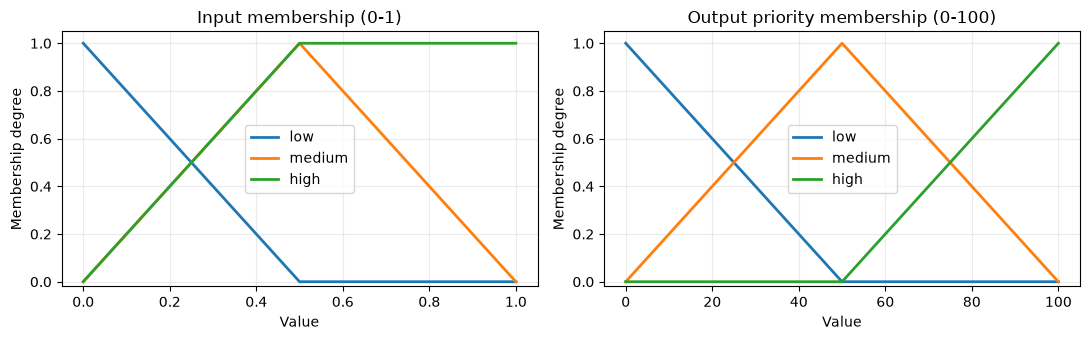

In [14]:
# Memvisualisasikan overlap; di x=0.5, medium dan high sama-sama aktif penuh.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for axis, membership, upper, title in [
    (axes[0], INPUT_MEMBERSHIP, 1, "Input membership (0-1)"),
    (axes[1], OUTPUT_MEMBERSHIP, 100, "Output priority membership (0-100)"),
]:
    universe = np.linspace(0, upper, 201)
    for name, points in membership.items():
        membership_function = fuzz.trapmf if len(points) == 4 else fuzz.trimf
        axis.plot(universe, membership_function(universe, points), label=name, linewidth=2)
    axis.set(title=title, xlabel="Value", ylabel="Membership degree", ylim=(-0.02, 1.05))
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
plt.show()


### Inferensi dan Pemilihan Tindakan

Syarat kelayakan sama dengan notebook pembanding: membela diri hanya saat ada tuduhan; membela orang lain saat ada penuduh dan pembela; menantang target perlu minimal dua penuduh berbeda, pressure ≥0.50, dan belum ada pembela; mengajak pemain diam perlu silence=1. Meminta informasi selalu tersedia. Syarat ini mencegah skor centroid rendah tetap menghasilkan tuduhan saat tidak ada pengamatan. Pengirim berbeda bukan bukti independen atau benar.

Aturan dan kurva dapat diubah di cell konfigurasi, kemudian jalankan kembali cell pembentukan sistem. Tidak perlu training NLU ulang.

In [15]:
# Menghitung prioritas dan menampilkan aturan aktif beserta kekuatan aktivasinya.
def evaluate_fuzzy(action, inputs):
    specification = FUZZY_RULES[action]
    names = specification["inputs"]
    values = {name: float(inputs[name]) for name in names}
    if any(not math.isfinite(value) or not 0 <= value <= 1 for value in values.values()):
        raise ValueError("Input fuzzy harus angka hingga dalam rentang 0-1.")

    simulation = FUZZY_SIMULATIONS[action]
    simulation.inputs(values)
    simulation.compute()
    score = float(simulation.output["priority"])

    terms = list(INPUT_MEMBERSHIP)
    first, second = list(FUZZY_SYSTEMS[action].antecedents)
    variables = {first.label: first, second.label: second}
    active_rules = []
    for i, first_term in enumerate(terms):
        first_strength = fuzz.interp_membership(
            variables[names[0]].universe, variables[names[0]][first_term].mf, values[names[0]],
        )
        for j, second_term in enumerate(terms):
            second_strength = fuzz.interp_membership(
                variables[names[1]].universe, variables[names[1]][second_term].mf, values[names[1]],
            )
            strength = min(first_strength, second_strength)
            if strength > 0:
                active_rules.append({
                    "input_1": f"{names[0]}={first_term}",
                    "input_2": f"{names[1]}={second_term}",
                    "output": specification["matrix"][i][j],
                    "activation": float(strength),
                })
    return score, pd.DataFrame(active_rules)


In [16]:
# Menilai tindakan yang layak lewat fuzzy, lalu memilih prioritas terbesar.
def choose_action(features, context, view):
    blocked = chat_permission(view)
    if blocked is not None:
        return blocked, pd.DataFrame([blocked])

    # Syarat kelayakan mencegah output fuzzy rendah menjadi tuduhan tanpa bukti pengamatan.
    candidates = [{
        "action": "ask_information", "intent": "neutral", "target": None,
        "inputs": {
            "uncertainty": context["uncertainty"],
            "few_messages": float(context["few_messages"]),
        },
        "reason": "Meminta informasi berdasarkan ketidakjelasan target/intent dan jumlah chat.",
    }]
    for row in features.sort_values("player").to_dict("records"):
        player = row["player"]
        if player == view["ai"]:
            if row["accusers"] > 0:
                candidates.append({
                    "action": "defend_self", "intent": "defend", "target": player,
                    "inputs": {"pressure": row["pressure"], "uncertainty": context["uncertainty"]},
                    "reason": f'{row["accusers"]} pemain berbeda menuduh AI dalam ronde ini.',
                })
            continue

        if row["accusers"] > 0 and row["defenders"] > 0:
            candidates.append({
                "action": "defend_player", "intent": "defend", "target": player,
                "inputs": {"pressure": row["pressure"], "support": row["support"]},
                "reason": f'{player} menerima tuduhan dan pembelaan; minta penilaian adil, bukan memastikan role.',
            })

        if (row["accusers"] >= MIN_ACCUSERS and row["pressure"] >= MIN_PRESSURE
                and row["defenders"] == 0):
            candidates.append({
                "action": "challenge_player", "intent": "offend", "target": player,
                "inputs": {"pressure": row["pressure"], "uncertainty": context["uncertainty"]},
                "reason": f'{player} dituduh {row["accusers"]} pemain berbeda; ini dugaan sosial, belum bukti Hitman.',
            })

        # silence tidak pernah masuk ke sistem fuzzy challenge_player.
        if row["silence"] >= 1.0:
            candidates.append({
                "action": "ask_quiet_player", "intent": "neutral", "target": player,
                "inputs": {"silence": row["silence"], "uncertainty": context["uncertainty"]},
                "reason": f'{player} belum chat minimal {SILENCE_SECONDS:g} detik siang; penyebab tidak diketahui.',
            })

    for candidate in candidates:
        candidate["score"], candidate["active_rules"] = evaluate_fuzzy(
            candidate["action"], candidate["inputs"],
        )

    # Nilai seri mengikuti urutan tetap: informasi dahulu, kemudian ID pemain.
    ranked = sorted(candidates, key=lambda item: round(item["score"], 10), reverse=True)
    winner = ranked[0]
    decision = {name: winner[name] for name in ("action", "intent", "target", "reason")}
    trace = pd.DataFrame([{
        "action": item["action"], "intent": item["intent"], "target": item["target"],
        "score": item["score"], "inputs": str(item["inputs"]),
        "active_rules": len(item["active_rules"]),
    } for item in ranked])
    return decision, trace


## Batas LLM untuk Percakapan

Fungsi berikut hanya membuat payload, tidak mengirim apa pun. Di game, LLM boleh menulis kalimat sesuai action/intent/target yang sudah diputuskan. Payload juga memberikan batas fakta. Instruksi ini belum merupakan jaminan bahwa generator akan patuh; integrasi game tetap perlu memvalidasi keluaran atau memakai template cadangan. Fungsi prediksi NLU dan resolver target tidak mengandalkan API anotasi dataset.

In [17]:
# Menyiapkan instruksi percakapan dari keputusan; tidak memanggil LLM/API.
def prepare_nlg(decision):
    return {
        "send_chat": decision["action"] != "wait",
        "intent": decision["intent"], "target": decision["target"],
        "action": decision["action"], "basis": decision["reason"],
        "constraints": [
            "Pertahankan intent dan target keputusan; jangan memilih target baru.",
            "Jangan mengklaim mengetahui role, hasil Peek, atau identitas korban tersembunyi.",
            "Tuduhan sosial bukan fakta role; sampaikan kecurigaan sebagai dugaan.",
            "Pembelaan pemain lain meminta evaluasi yang adil, bukan memastikan ia warga.",
        ],
    }


## Simulasi, Tabel Parameter, dan Keputusan

### Contoh dengan Intent yang Sudah Diketahui

Simulasi label tetap memisahkan pemeriksaan kebijakan dari kesalahan classifier. Tidak memakai role rahasia.

In [18]:
# Metadata contoh berasal dari pengamatan publik dan izin bicara AI sendiri.
view = {
    "players": PLAYERS, "ai": AI_NAME, "round": 1, "phase": "day",
    "day_start": 0.0, "now": 45.0, "can_chat": True,
}

# Label contoh ditetapkan untuk menguji kebijakan, bukan hasil akurasi NLU.
demo_specs = [
    ("e1", "A", "AI pasti Hitman", "offend", 10.0),
    ("e2", "B", "Vote AI", "offend", 15.0),
    ("e3", "C", "D pasti Hitman", "offend", 20.0),
    ("e4", "E", "Vote D", "offend", 25.0),
    ("e5", "B", "D bukan Hitman", "defend", 30.0),
]
demo_events = []
for event_id, speaker, text, intent, moment in demo_specs:
    targets, source = extract_targets(text, intent, speaker, PLAYERS)
    demo_events.append({
        "id": event_id, "speaker": speaker, "text": text, "round": 1,
        "phase": "day", "time": moment, "intent": intent, "confidence": 1.0,
        "targets": targets, "target_source": source,
    })

features, context = build_features(demo_events, view)
show_table(features)
show_table(pd.DataFrame([context]))


player,accusers,defenders,pressure,support,silence,chat_count,accuser_names,defender_names
A,0,0,0.000,0.000,0.583,1,[],[]
AI,2,0,0.400,0.000,0.750,0,"['A', 'B']",[]
B,0,0,0.000,0.000,0.250,2,[],[]
C,0,0,0.000,0.000,0.417,1,[],[]
D,2,1,0.500,0.250,0.750,0,"['C', 'E']",['B']
E,0,0,0.000,0.000,0.333,1,[],[]


uncertainty,few_messages,message_count
0.000,False,5


In [19]:
decision, trace = choose_action(features, context, view)
show_table(pd.DataFrame([decision]))
show_table(trace)
show_table(pd.DataFrame([prepare_nlg(decision)]))


action,intent,target,reason
defend_self,defend,AI,2 pemain berbeda menuduh AI dalam ronde ini.


action,intent,target,score,inputs,active_rules
defend_self,defend,AI,67.255,"{'pressure': 0.4, 'uncertainty': 0.0}",3
defend_player,defend,D,55.952,"{'pressure': 0.5, 'support': 0.25}",6
ask_information,neutral,—,16.667,"{'uncertainty': 0.0, 'few_messages': 0.0}",1


send_chat,intent,target,action,basis,constraints
True,defend,AI,defend_self,2 pemain berbeda menuduh AI dalam ronde ini.,"['Pertahankan intent dan target keputusan; jangan memilih target baru.', 'Jangan mengklaim mengetahui role, hasil Peek, atau identitas korban tersembunyi.', 'Tuduhan sosial bukan fakta role; sampaikan kecurigaan sebagai dugaan.', 'Pembelaan pemain lain meminta evaluasi yang adil, bukan memastikan ia warga.']"


### Alasan Fuzzy untuk Tindakan Terpilih

Activation adalah derajat aktif aturan (0–1), bukan confidence NLU atau peluang Hitman. Skor final berasal dari centroid gabungan output aturan, bukan rata-rata sederhana activation.

In [20]:
# Memperlihatkan aturan aktif pada keputusan contoh.
if decision["action"] != "wait":
    selected_row = features.set_index("player")
    selected_inputs = {
        "uncertainty": context["uncertainty"], "few_messages": float(context["few_messages"]),
    }
    if decision["target"] is not None:
        selected_inputs.update(selected_row.loc[decision["target"]].to_dict())
    selected_score, active_rules = evaluate_fuzzy(decision["action"], selected_inputs)
    print(f"Prioritas fuzzy: {selected_score:.3f}")
    show_table(active_rules)


Prioritas fuzzy: 67.255


input_1,input_2,output,activation
pressure=low,uncertainty=low,medium,0.200
pressure=medium,uncertainty=low,high,0.800
pressure=high,uncertainty=low,high,0.800


### Beberapa Situasi Permainan

In [21]:
# Memeriksa keputusan pada situasi yang bisa ditentukan tanpa mengetahui role rahasia.
ambiguous_events = [
    dict(demo_events[0], id="unknown_1", speaker="C", text="Dia sus", targets=[]),
    dict(demo_events[0], id="unknown_2", speaker="E", text="Kamu sus", targets=[]),
]
scenario_results = []
for name, scenario_events, scenario_view in [
    ("Tidak ada chat", [], view),
    ("AI dituduh", demo_events[:2], view),
    ("Tuduhan dan pembelaan D", demo_events[2:], view),
    ("D dituduh dua pemain", demo_events[2:4], view),
    ("Fase malam", demo_events, {**view, "phase": "night"}),
    ("AI tidak bisa chat", demo_events, {**view, "can_chat": False}),
    ("Diam lama tanpa tuduhan", [], {**view, "now": 90.0}),
    ("Satu tuduhan AI + dua target ambigu", [demo_events[0], *ambiguous_events], view),
]:
    table, summary = build_features(scenario_events, scenario_view)
    selected, _ = choose_action(table, summary, scenario_view)
    scenario_results.append({"scenario": name, **selected})

show_table(pd.DataFrame(scenario_results))


scenario,action,intent,target,reason
Tidak ada chat,ask_information,neutral,—,Meminta informasi berdasarkan ketidakjelasan target/intent dan jumlah chat.
AI dituduh,defend_self,defend,AI,2 pemain berbeda menuduh AI dalam ronde ini.
Tuduhan dan pembelaan D,defend_player,defend,D,"D menerima tuduhan dan pembelaan; minta penilaian adil, bukan memastikan role."
D dituduh dua pemain,challenge_player,offend,D,"D dituduh 2 pemain berbeda; ini dugaan sosial, belum bukti Hitman."
Fase malam,wait,—,—,Bukan fase diskusi siang.
AI tidak bisa chat,wait,—,—,AI tidak memiliki izin mengirim chat.
Diam lama tanpa tuduhan,ask_quiet_player,neutral,A,A belum chat minimal 60 detik siang; penyebab tidak diketahui.
Satu tuduhan AI + dua target ambigu,ask_information,neutral,—,Meminta informasi berdasarkan ketidakjelasan target/intent dan jumlah chat.


### Integrasi Model NLU yang Sudah Dilatih

Cell ini benar-benar membaca model lokal. Bandingkan label dan keputusan dengan simulasi sebelumnya; perbedaan prediksi model dapat mengubah keputusan. Tidak ada training ulang.

In [22]:
# Menguji model NLU tersimpan dan resolver target lokal, tanpa training atau API.
runtime = load_nlu()
live_events = [
    annotate_event({
        "id": event_id, "speaker": speaker, "text": text,
        "round": 1, "phase": "day", "time": moment,
    }, runtime, PLAYERS)
    for event_id, speaker, text, _, moment in demo_specs
]
show_table(pd.DataFrame(live_events)[[
    "speaker", "text", "intent", "confidence", "targets", "target_source",
]])
live_features, live_context = build_features(live_events, view)
live_decision, live_trace = choose_action(live_features, live_context, view)
show_table(pd.DataFrame([live_decision]))
show_table(live_trace)


speaker,text,intent,confidence,targets,target_source
A,AI pasti Hitman,offend,0.867,['AI'],aturan_teks
B,Vote AI,offend,0.921,['AI'],aturan_teks
C,D pasti Hitman,offend,0.867,['D'],aturan_teks
E,Vote D,offend,0.921,['D'],aturan_teks
B,D bukan Hitman,defend,0.973,['D'],aturan_teks


action,intent,target,reason
defend_self,defend,AI,2 pemain berbeda menuduh AI dalam ronde ini.


action,intent,target,score,inputs,active_rules
defend_self,defend,AI,67.255,"{'pressure': 0.4, 'uncertainty': 0.0}",3
defend_player,defend,D,55.952,"{'pressure': 0.5, 'support': 0.25}",6
ask_information,neutral,—,16.667,"{'uncertainty': 0.0, 'few_messages': 0.0}",1


## Review dan Pengujian

Checks berikut memeriksa konsistensi implementasi: target eksplisit, negasi, ketidakjelasan, batas ronde, spam, izin aksi, dan ketidakbergantungan pada field rahasia. Lulus checks bukan bukti bahwa strategi menang melawan manusia.

In [23]:
# Pengujian kebijakan dan aliran informasi; bukan pengukuran win rate atau akurasi model.
checks = []
for text, intent, speaker, reply_to, expected in [
    ("Vote B", "offend", "A", None, ["B"]),
    ("Aku curiga B", "offend", "A", None, ["B"]),
    ("B bukan Hitman", "defend", "A", None, ["B"]),
    ("Aku bukan Hitman", "defend", "A", None, ["A"]),
    ("Vote aku", "offend", "A", None, ["A"]),
    ("Kamu Hitman", "offend", "A", None, []),
    ("Kamu Hitman", "offend", "A", "B", ["B"]),
    ("Dia Hitman", "offend", "A", "B", []),
    ("B kena Gag Order", "offend", "A", None, []),
    ("Jangan vote B", "offend", "A", None, []),
    ("Jangan vote B", "defend", "A", None, ["B"]),
    ("Kalau B Hitman, vote B", "offend", "A", None, []),
    ("Vote B, vote C", "offend", "A", None, ["B", "C"]),
    ("Kapan mulai?", "neutral", "A", None, []),
]:
    found, _ = extract_targets(text, intent, speaker, PLAYERS, reply_to)
    assert found == expected, (text, found, expected)
checks.append({"check": "14 kasus target, negasi, diri sendiri, reply-to", "result": "lulus"})

base_table, base_context = build_features(demo_events, view)
spam = [dict(demo_events[0], id=f"spam_{i}") for i in range(20)]
spam_table, _ = build_features([*demo_events, *spam, demo_events[0]], view)
assert base_table["accusers"].tolist() == spam_table["accusers"].tolist()
checks.append({"check": "Spam dan event duplikat tidak menambah jumlah penuduh", "result": "lulus"})

old_events = [dict(event, round=0) for event in demo_events]
old_table, _ = build_features(old_events, view)
assert old_table["accusers"].sum() == 0
low_table, _ = build_features([dict(event, confidence=0.1) for event in demo_events], view)
assert low_table["accusers"].sum() == 0
checks.append({"check": "Ronde lama dan confidence rendah tidak menjadi tuduhan", "result": "lulus"})

for changed_view in [{**view, "phase": "night"}, {**view, "phase": "tribunal"}, {**view, "can_chat": False}]:
    selected, _ = choose_action(base_table, base_context, changed_view)
    assert selected["action"] == "wait" and selected["intent"] is None
checks.append({"check": "Malam, tribunal, atau tanpa izin chat menghasilkan wait", "result": "lulus"})

hidden = [dict(event, role_asli="Hitman", hostage=True, gag_order=True) for event in demo_events]
hidden_table, hidden_context = build_features(hidden, {**view, "private_peek": {"B": "Hitman"}})
pd.testing.assert_frame_equal(hidden_table, base_table)
assert hidden_context == base_context
checks.append({"check": "Tambahan field rahasia tidak mengubah parameter", "result": "lulus"})

quiet_table, quiet_context = build_features([], {**view, "now": 90.0})
assert quiet_table["pressure"].sum() == 0
quiet_decision, _ = choose_action(quiet_table, quiet_context, {**view, "now": 90.0})
assert quiet_decision["intent"] == "neutral"
checks.append({"check": "Diam saja tidak menyebabkan offend", "result": "lulus"})

table, summary = build_features(demo_events[2:4], view)
selected, _ = choose_action(table, summary, view)
assert selected["intent"] == "offend" and selected["target"] == "D"
table, summary = build_features(demo_events[2:], view)
selected, _ = choose_action(table, summary, view)
assert selected["intent"] == "defend" and selected["target"] == "D"
checks.append({"check": "Tuduhan bersama dan konflik pembelaan memilih target D", "result": "lulus"})

show_table(pd.DataFrame(checks))


check,result
"14 kasus target, negasi, diri sendiri, reply-to",lulus
Spam dan event duplikat tidak menambah jumlah penuduh,lulus
Ronde lama dan confidence rendah tidak menjadi tuduhan,lulus
"Malam, tribunal, atau tanpa izin chat menghasilkan wait",lulus
Tambahan field rahasia tidak mengubah parameter,lulus
Diam saja tidak menyebabkan offend,lulus
Tuduhan bersama dan konflik pembelaan memilih target D,lulus


### Pengujian Cakupan dan Batas Fuzzy

Grid 11×11 untuk setiap tindakan mencakup 0, 0.5, dan 1. Tes memeriksa output hingga, aturan aktif, rentang nilai, serta arah kurva pembelaan diri. Ini verifikasi numerik dan perilaku rancangan, bukan evaluasi strategi pertandingan.

In [24]:
# Mencoba seluruh kombinasi grid termasuk 0, tepat 0.5, dan 1.
# Kelengkapan aturan memastikan tidak ada lubang pada batas seperti desain lama.
coverage_rows = []
for action, specification in FUZZY_RULES.items():
    scores = []
    for first_value in np.linspace(0, 1, 11):
        for second_value in np.linspace(0, 1, 11):
            score, rules = evaluate_fuzzy(action, dict(zip(
                specification["inputs"], [first_value, second_value],
            )))
            assert math.isfinite(score) and 0 <= score <= 100 and not rules.empty
            scores.append(score)
    coverage_rows.append({
        "action": action, "combinations": len(scores),
        "min_priority": min(scores), "max_priority": max(scores), "result": "lulus",
    })
show_table(pd.DataFrame(coverage_rows))

# Input eksternal yang tidak valid harus dihentikan, bukan menghasilkan prioritas palsu.
for invalid in [float("nan"), float("inf"), -0.1, 1.1]:
    try:
        evaluate_fuzzy("defend_self", {"pressure": invalid, "uncertainty": 0.0})
    except ValueError:
        pass
    else:
        raise AssertionError("Input fuzzy tidak valid diterima.")

# Pada ketidakjelasan tetap nol, menambah tekanan tidak boleh menurunkan prioritas pembelaan.
self_curve = [
    evaluate_fuzzy("defend_self", {"pressure": p, "uncertainty": 0.0})[0]
    for p in np.linspace(0, 1, 21)
]
assert np.all(np.diff(self_curve) >= -1e-8)
print("605 kombinasi input tercakup; input tidak valid ditolak; kurva pembelaan diperiksa.")


action,combinations,min_priority,max_priority,result
ask_information,121,16.667,83.333,lulus
defend_self,121,16.667,83.333,lulus
defend_player,121,16.667,83.333,lulus
challenge_player,121,16.667,83.333,lulus
ask_quiet_player,121,16.667,83.333,lulus


605 kombinasi input tercakup; input tidak valid ditolak; kurva pembelaan diperiksa.


### Evaluasi yang Diperlukan Sebelum Dipakai sebagai Hasil Penelitian

1. Anotasi manual target pada sampel chat nyata; ukur precision, recall, exact-match multi-target, serta proporsi tidak diketahui. Nilai salah target dan abstain harus dilaporkan terpisah.
2. Bandingkan Utility AI, Behavior Tree, dan fuzzy pada skenario/event yang sama. Ukur salah tuduh warga, kemampuan membela diri, ketepatan target, latensi, dan kepatuhan izin chat.
3. Setelah simulator tersedia, ukur win rate dan variasi antar-seed melawan beberapa strategi lawan. Pilih bobot/ambang di skenario pengembangan, bukan dari pertandingan test akhir.
4. Uji penghapusan satu parameter (misalnya silence) dan perubahan ambang untuk mengetahui apakah parameter itu membantu. Dua penuduh berbeda tidak menjamin bukti independen.
5. Penjadwal chat/cooldown perlu ditetapkan oleh game agar pemanggilan berulang tidak menghasilkan spam. Notebook memilih satu aksi per permintaan dan belum mengirim chat atau mengubah server game.

### Sumber Konsep dan Asal Angka

Implementasi Mamdani, membership function, ControlSystemSimulation, dan defuzzifikasi mengikuti [dokumentasi resmi scikit-fuzzy](https://scikit-fuzzy.readthedocs.io/en/latest/auto_examples/plot_tipping_problem_newapi.html). Pemeriksaan grid input mengikuti gagasan evaluasi ruang kontrol pada [contoh lanjutan resmi](https://scikit-fuzzy.readthedocs.io/en/latest/auto_examples/plot_control_system_advanced.html).

**Sumber tersebut menjelaskan metode, bukan parameter khusus HOSTAGE.** Mekanik dan batas informasi berasal dari konsep game pengguna. Titik kurva, isi matriks, confidence 0.60, dua penuduh, ambang tekanan 0.50, dan 60 detik adalah rancangan awal. Angka perlu dituning pada skenario pengembangan lalu diuji terpisah; bukan diklaim sebagai standar ilmiah.

Perbandingan adil dengan Utility AI/Behavior Tree memerlukan event, NLU, target, dan batas informasi yang sama. Prioritas fuzzy bukan probabilitas Hitman atau kebenaran tuduhan.